### Important imports

In [4]:
import numpy as np 
import torch
from torch.utils.data import Dataset,DataLoader
import glob
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt 
import cv2
from itertools import islice
import torch.nn as nn 
import torch.nn.functional as F


### Reading the Images & Reshaping


In [5]:
pneumonia  = []
path = './chest_xray/train/PNEUMONIA/*.jpeg' 

#glob allows to walk through a directory 
#cv2 is used for reading images, specially multichannel ones(RGB)
for f in islice(glob.iglob(path), 200):
    img = cv2.imread(f)
    img = cv2.resize(img,(256,256))
    b,g,r = cv2.split(img) #reordering the rgb
    img = cv2.merge([r,g,b]) 
    pneumonia.append(img)


In [6]:
healthy = []
path = './chest_xray/train/NORMAL/*.jpeg'

for f in islice(glob.iglob(path), 200):
    img = cv2.imread(f)
    img = cv2.resize(img,(256,256))
    b,g,r = cv2.split(img)
    img = cv2.merge([r,g,b]) 
    healthy.append(img)

In [7]:
all_imgs = np.concatenate((healthy,pneumonia))


### Visualizing the Images

In [8]:
#matplotlib is used for visuzaling imgs

def show_random_imgs(healthy,pneumonia,img_num):
    
    healthy_img = healthy[np.random.choice(healthy.shape[0],img_num, replace = False)]
    pneumonia_imgs = pneumonia[np.random.choice(pneumonia.shape[0],img_num, replace = False)]
    plt.figure(figsize=(15,9))

    for i in range(img_num):
        plt.subplot(1,img_num, i+1)
        plt.title('Healthy')
        plt.imshow(healthy_img[i])

    plt.figure(figsize=(15,9))
    for i in range(img_num):
        plt.subplot(1,img_num, i+1)
        plt.title('Pneumonia')
        plt.imshow(pneumonia_imgs[i])

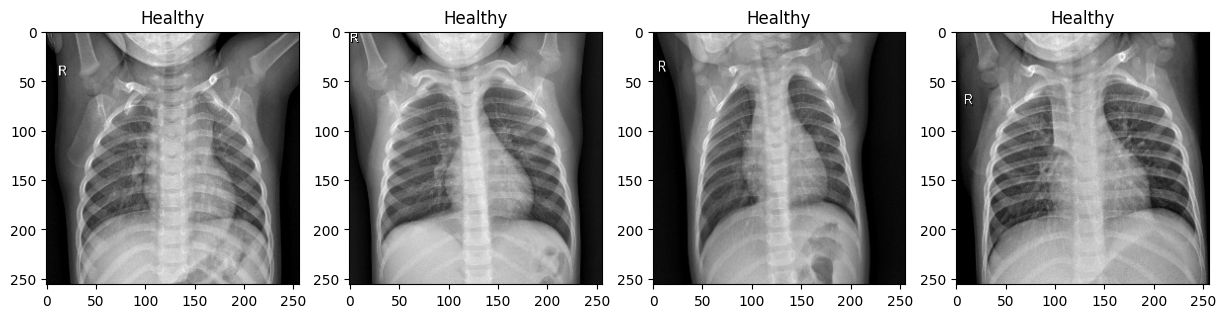

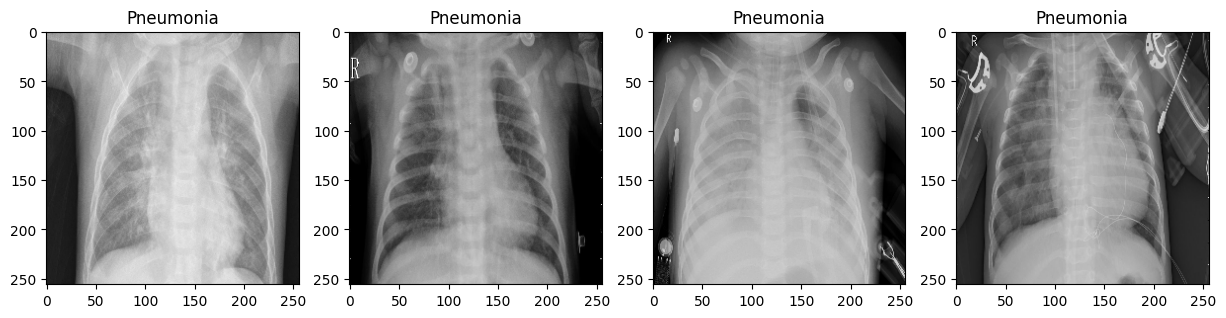

In [9]:
healthy = np.array(healthy)
pneumonia = np.array(pneumonia)

show_random_imgs(healthy,pneumonia,4)

### Dataset Class

In [10]:
class MRI(Dataset):
    def __init__(self): #loads all the data 
        pneumonia  = []
        healthy = []
        path = './chest_xray/train/PNEUMONIA/*.jpeg' 

        #glob allows to walk through a directory 
        #cv2 is used for reading images, specially multichannel ones(RGB)
        for f in islice(glob.iglob(path), 200):
            img = cv2.imread(f)
            img = cv2.resize(img,(256,256))
            b,g,r = cv2.split(img) #reordering the rgb
            img = cv2.merge([r,g,b]) 
            pneumonia.append(img)

        path = './chest_xray/train/NORMAL/*.jpeg'
        for f in islice(glob.iglob(path), 200):
            img = cv2.imread(f)
            img = cv2.resize(img,(256,256))
            b,g,r = cv2.split(img)
            img = cv2.merge([r,g,b]) 
            healthy.append(img)
        
        #images
        healthy = np.array(healthy, dtype=np.float32)
        pneumonia = np.array(pneumonia, dtype=np.float32)

        #labels
        pneumonia_label = np.ones(pneumonia.shape[0],dtype = np.float32)
        healthy_label = np.zeros(healthy.shape[0],dtype = np.float32)

        self.images = np.concatenate((pneumonia,healthy),axis = 0)
        self.labels = np.concatenate((pneumonia_label,healthy_label),axis = 0)

    def __getitem__(self,index):
        sample = {'image':self.images[index],'label':self.labels[index]}
        return sample
    
    def __len__(self):
        return self.images.shape[0]
    
    def normalize(self):
        self.images = self.images/256.0
    


### The Model

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.cnn_model = nn.Sequential(
            nn.Conv2d(in_channels= 3, out_channels = 6, kernel_size = 5),#the outchannels are the number of convolutional filters 
            nn.Tanh(), #gives a non_linearily to theout_channels so that the model can learn complex patterns
            nn.AvgPool2d(kernel_size = 2, stride =  5),
            nn.Conv2d(in_channels = 6, out_channels = 16 , kernel_size = 5),
            nn.Tanh(), 
            nn.AvgPool2d(kernel_size = 2, stride =  5))  
        
        self.fc_model = nn.Sequential( #fully connected model
            nn.Linear(in_features = 1600,out_features= 220),
            nn.Tanh(), 
            nn.Linear(in_features = 220 ,out_features= 120),
            nn.Tanh(), 
            nn.Linear(in_features = 120,out_features= 1))
        
    def forward(self, x):
        x = self.cnn_model(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc_model(x)
        x = F.sigmoid(x)

        return x


        


In [43]:
model = CNN().to('cpu')
mri_dataset = MRI()
mri_dataset.normalize()


### Training the model

In [50]:
eta = 0.0001 # the learning rate
epochs = 400
device  = 'cpu'
optimizer = torch.optim.Adam(model.parameters(),lr = eta)
dataloader = DataLoader(mri_dataset,batch_size = 32, shuffle = True)
model.train()

for epoch in range(1, epochs + 1):
    epoch_loss = 0  # Initialize the cumulative loss for the epoch
    dataloader = DataLoader(mri_dataset, batch_size=32, shuffle=True)
    
    # Loop through each batch of data
    for img in dataloader:
        optimizer.zero_grad()  # Clear the gradients
        data = img['image'].to(device)  # Get the input data
        data = data.permute(0, 3, 1, 2)  # Permute to (batch_size, channels, height, width)
        label = img['label'].to(device)  # Get the labels

        # Forward pass
        y = model(data)
        
        # Calculate the loss (binary cross-entropy)
        error = nn.BCELoss()
        loss = error(y.squeeze(), label)  # Use the squeeze method to remove extra dimensions
        
        # Backward pass and optimization step
        loss.backward()
        optimizer.step()
        
        # Accumulate loss for the current batch
        epoch_loss += loss.item()
    
    # Print the average loss for the epoch after every 10 epochs
    if epoch % 10 == 0:
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch {epoch}/{epochs}, Average Loss: {avg_loss:.4f}")
        
        

Epoch 10/400, Average Loss: 0.1458
Epoch 20/400, Average Loss: 0.1169
Epoch 30/400, Average Loss: 0.0941
Epoch 40/400, Average Loss: 0.0789
Epoch 50/400, Average Loss: 0.1083
Epoch 60/400, Average Loss: 0.0458
Epoch 70/400, Average Loss: 0.0333
Epoch 80/400, Average Loss: 0.0275
Epoch 90/400, Average Loss: 0.0119
Epoch 100/400, Average Loss: 0.0067
Epoch 110/400, Average Loss: 0.0045
Epoch 120/400, Average Loss: 0.0034
Epoch 130/400, Average Loss: 0.0024
Epoch 140/400, Average Loss: 0.0016
Epoch 150/400, Average Loss: 0.0014
Epoch 160/400, Average Loss: 0.0011
Epoch 170/400, Average Loss: 0.0009
Epoch 180/400, Average Loss: 0.0008
Epoch 190/400, Average Loss: 0.0006
Epoch 200/400, Average Loss: 0.0006
Epoch 210/400, Average Loss: 0.0005
Epoch 220/400, Average Loss: 0.0004
Epoch 230/400, Average Loss: 0.0004
Epoch 240/400, Average Loss: 0.0003
Epoch 250/400, Average Loss: 0.0003
Epoch 260/400, Average Loss: 0.0002
Epoch 270/400, Average Loss: 0.0002
Epoch 280/400, Average Loss: 0.0002
E